# 🚀 Spaceship Titanic — Exploratory Data Analysis

Notebook EDA lengkap untuk dataset Spaceship Titanic dari Kaggle.

**Struktur notebook:**
1. Setup & import library
2. Load data
3. Inspeksi awal
4. Missing values
5. Distribusi variabel numerik
6. Distribusi variabel kategorik
7. Analisis target (Transported)
8. Analisis fitur vs target
9. Feature engineering awal
10. Korelasi & heatmap
11. Outlier detection
12. Ringkasan temuan

## 1. Setup & Import Library

In [1]:
# Install jika belum tersedia
# !pip install pandas numpy matplotlib seaborn scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Gaya global ──────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Palet warna konsisten
C_FALSE = '#3266ad'   # Not Transported
C_TRUE  = '#1d9e75'   # Transported
PALETTE = [C_FALSE, C_TRUE]

print('✅ Library berhasil di-import')

✅ Library berhasil di-import


## 2. Load Data

In [2]:
# ── Upload file di Google Colab ───────────────────────────────
# Cara 1: Upload manual
# from google.colab import files
# uploaded = files.upload()  # upload train.csv dan test.csv

# Cara 2: Mount Google Drive (jika file sudah ada di Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# TRAIN_PATH = '/content/drive/MyDrive/spaceship-titanic/train.csv'
# TEST_PATH  = '/content/drive/MyDrive/spaceship-titanic/test.csv'

# Cara 3: Kaggle API (uncomment jika pakai)
# !pip install kaggle -q
# from google.colab import files
# files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle competitions download -c spaceship-titanic
# !unzip spaceship-titanic.zip

# ── Default: file sudah ada di /content/ ─────────────────────
TRAIN_PATH = 'train.csv'
TEST_PATH  = 'test.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f'Train shape : {train.shape}')
print(f'Test shape  : {test.shape}')
train.head()

Train shape : (8693, 14)
Test shape  : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 3. Inspeksi Awal

In [3]:
print('=' * 55)
print('INFO DATASET')
print('=' * 55)
train.info()
print()
print('=' * 55)
print('STATISTIK DESKRIPTIF — NUMERIK')
print('=' * 55)
train.describe().round(2)

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB

STATISTIK DESKRIPTIF — NUMERIK


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.00,8512.00,8510.00,8485.00,8510.00,8505.00
mean,28.83,224.69,458.08,173.73,311.14,304.85
std,14.49,666.72,1611.49,604.70,1136.71,1145.72
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,19.00,0.00,0.00,0.00,0.00,0.00
50%,27.00,0.00,0.00,0.00,0.00,0.00
75%,38.00,47.00,76.00,27.00,59.00,46.00
max,79.00,14327.00,29813.00,23492.00,22408.00,24133.00


In [4]:
print('STATISTIK DESKRIPTIF — KATEGORIK')
train.describe(include='object')

STATISTIK DESKRIPTIF — KATEGORIK


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,VIP,Name
count,8693,8492,8476,8494,8511,8490,8493
unique,8693,3,2,6560,3,2,8473
top,0001_01,Earth,False,G/734/S,TRAPPIST-1e,False,Anton Woody
freq,1,4602,5439,8,5915,8291,2


In [5]:
# Duplikat
print(f'Duplikat baris : {train.duplicated().sum()}')

# Jumlah unik per kolom
print('\nNilai unik per kolom:')
print(train.nunique().to_string())

Duplikat baris : 0

Nilai unik per kolom:
PassengerId     8693
HomePlanet         3
CryoSleep          2
Cabin           6560
Destination        3
Age               80
VIP                2
RoomService     1273
FoodCourt       1507
ShoppingMall    1115
Spa             1327
VRDeck          1306
Name            8473
Transported        2


## 4. Missing Values

In [6]:
def missing_summary(df, label='Train'):
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct  = (miss / len(df) * 100).round(2)
    return pd.DataFrame({'Missing': miss, 'Pct (%)': pct}).rename_axis(f'{label} — Kolom')

print(missing_summary(train, 'Train').to_string())
print()
print(missing_summary(test, 'Test').to_string())

               Missing  Pct (%)
Train — Kolom                  
CryoSleep          217     2.50
ShoppingMall       208     2.39
VIP                203     2.34
HomePlanet         201     2.31
Name               200     2.30
Cabin              199     2.29
VRDeck             188     2.16
FoodCourt          183     2.11
Spa                183     2.11
Destination        182     2.09
RoomService        181     2.08
Age                179     2.06

              Missing  Pct (%)
Test — Kolom                  
FoodCourt         106     2.48
Spa               101     2.36
Cabin             100     2.34
ShoppingMall       98     2.29
Name               94     2.20
VIP                93     2.17
CryoSleep          93     2.17
Destination        92     2.15
Age                91     2.13
HomePlanet         87     2.03
RoomService        82     1.92
VRDeck             80     1.87


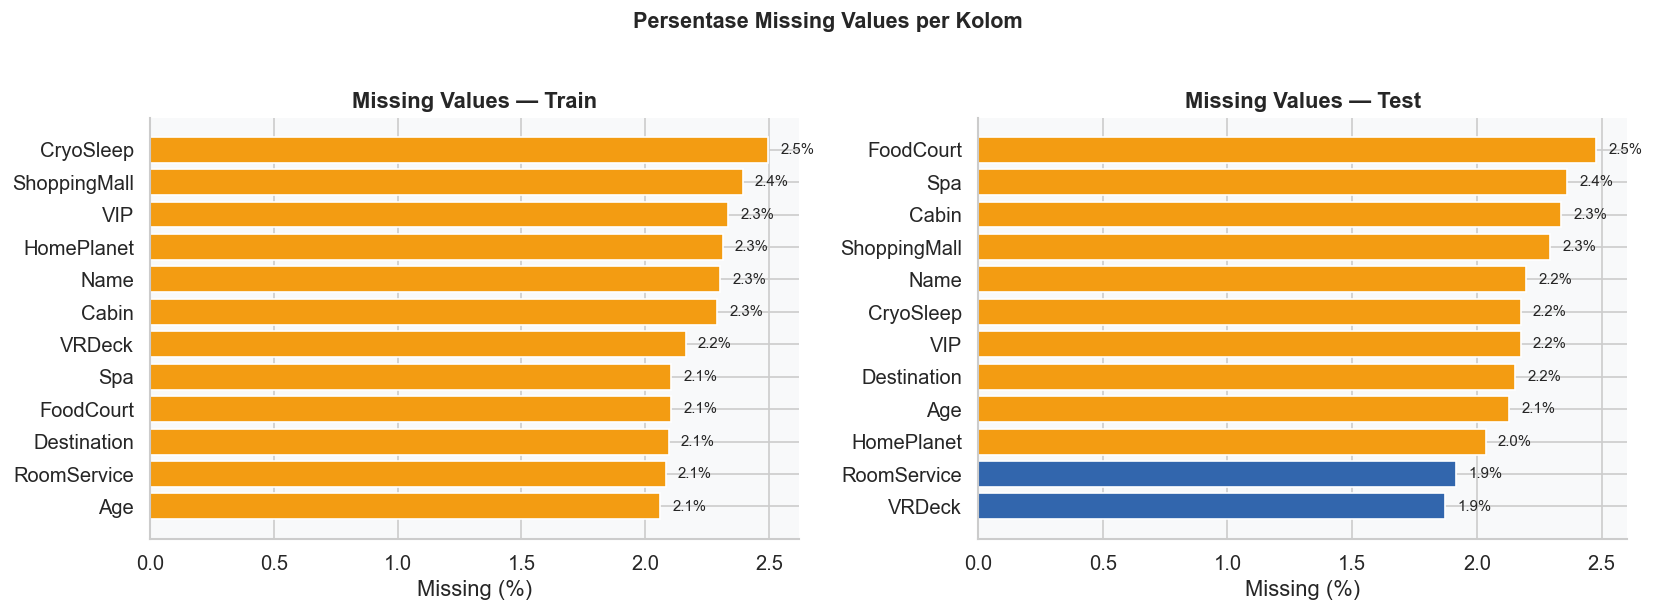

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, label) in zip(axes, [(train, 'Train'), (test, 'Test')]):
    miss = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
    miss = miss[miss > 0]
    colors = ['#e74c3c' if v > 5 else '#f39c12' if v > 2 else '#3266ad' for v in miss.values]
    bars = ax.barh(miss.index, miss.values, color=colors, edgecolor='white')
    ax.set_xlabel('Missing (%)')
    ax.set_title(f'Missing Values — {label}', fontweight='bold')
    for bar, val in zip(bars, miss.values):
        ax.text(val + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.suptitle('Persentase Missing Values per Kolom', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()

## 5. Distribusi Variabel Numerik

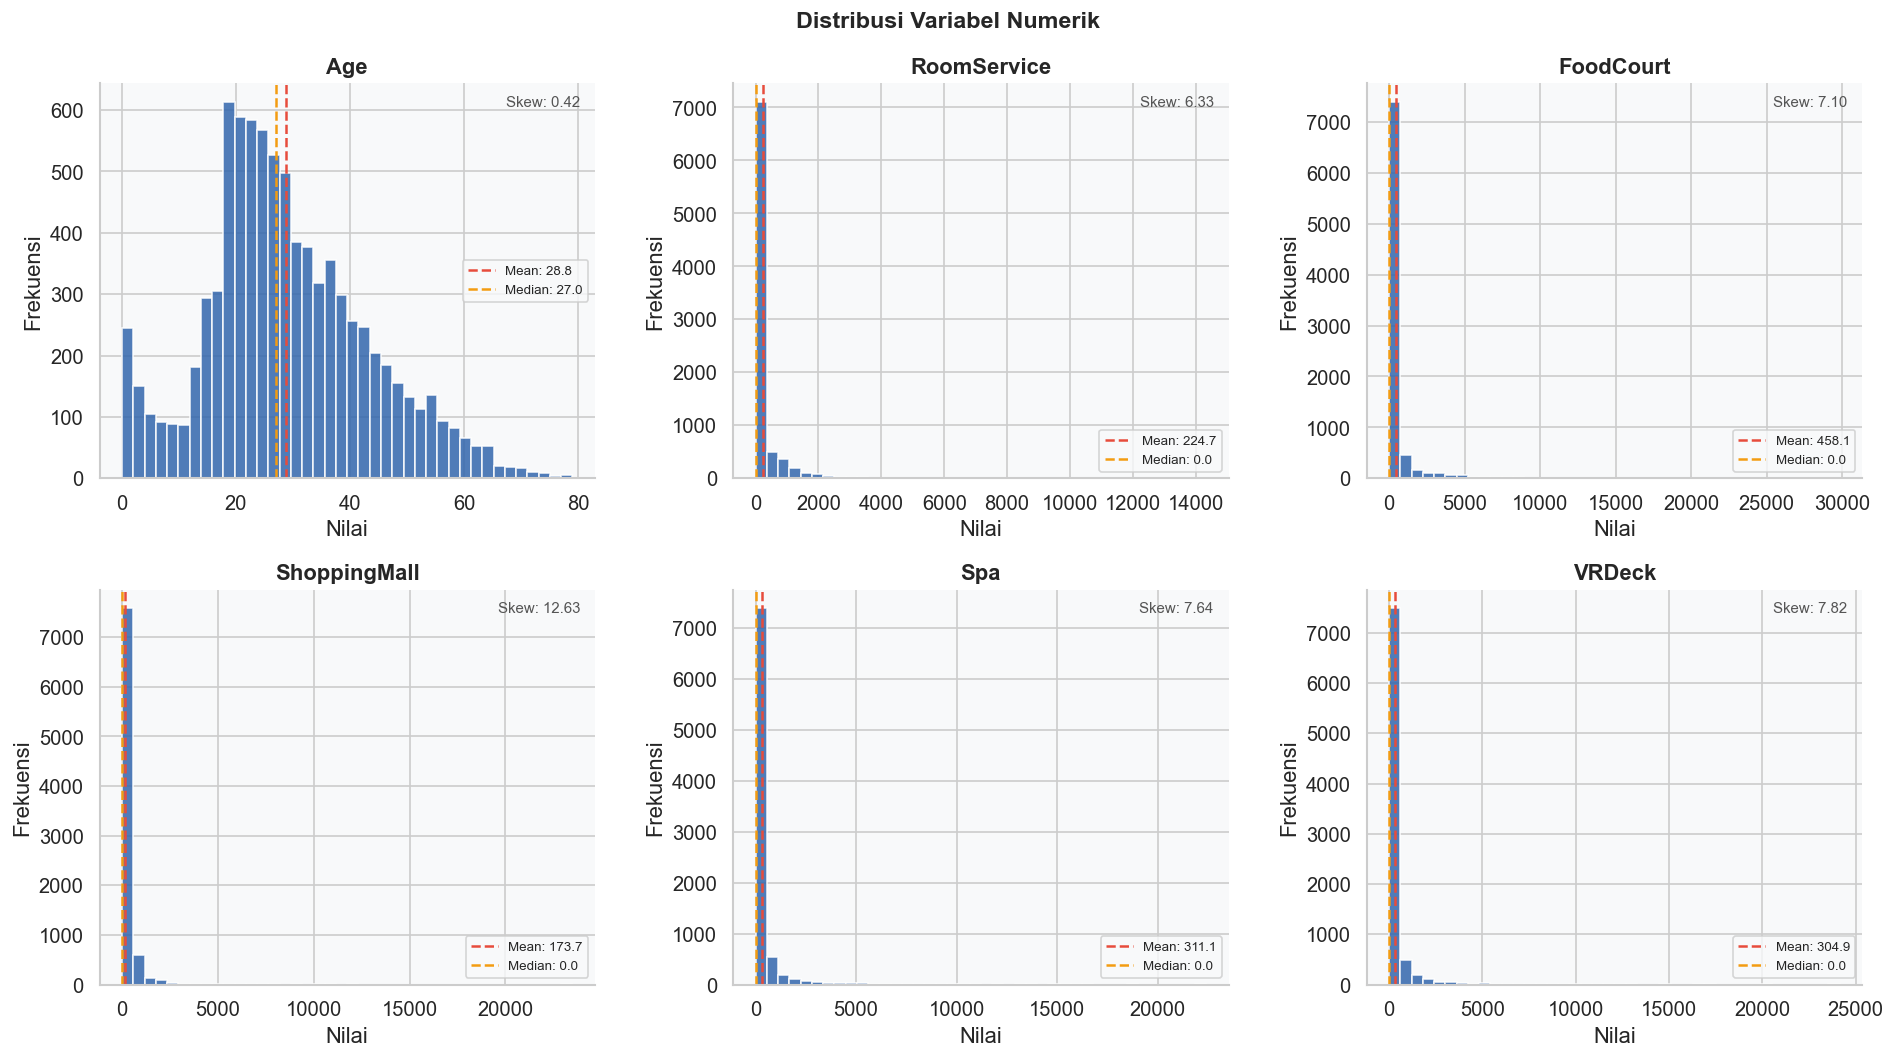

In [8]:
NUM_COLS  = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
CAT_COLS  = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
SPEND_COLS = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    data = train[col].dropna()
    ax.hist(data, bins=40, color='#3266ad', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='#f39c12', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Nilai')
    ax.set_ylabel('Frekuensi')
    skew = data.skew()
    ax.text(0.97, 0.97, f'Skew: {skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#555')
    ax.legend(fontsize=8)

plt.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_numerik.png', bbox_inches='tight')
plt.show()

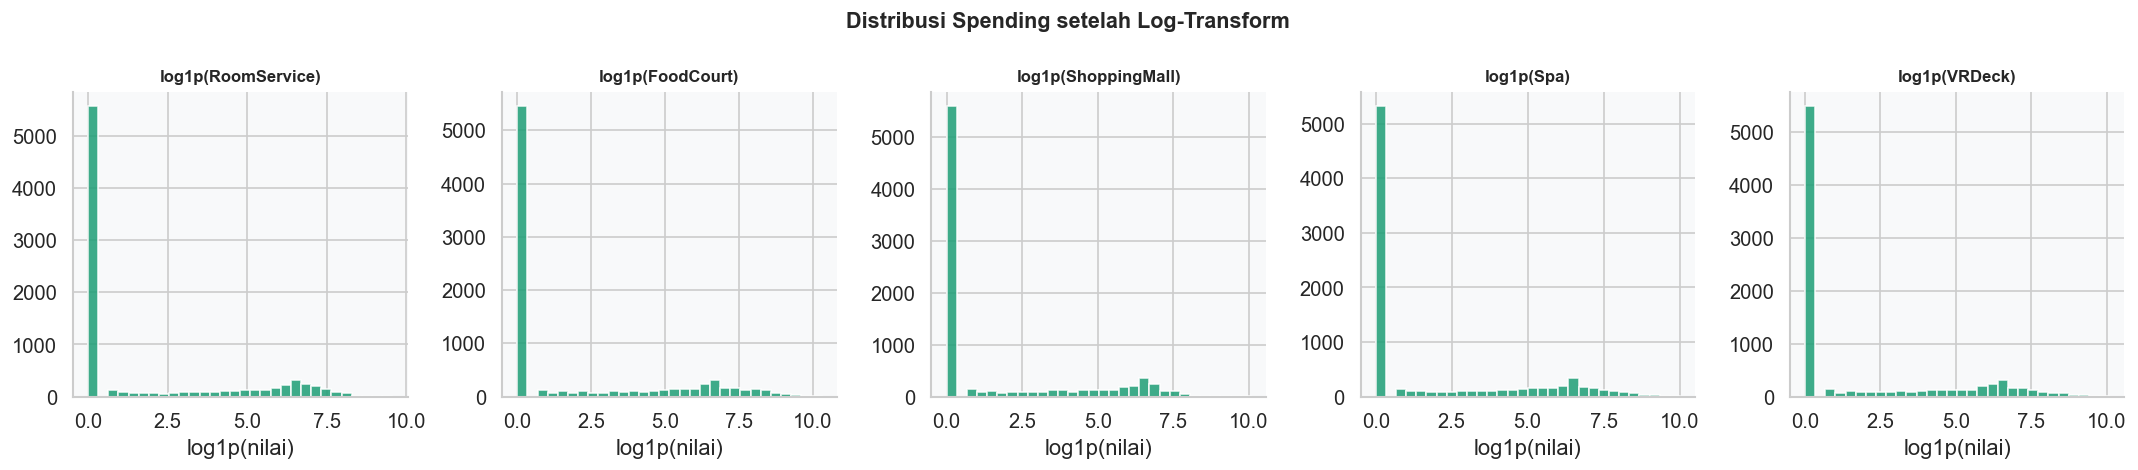

In [9]:
# Log-transform distribusi spending (karena sangat right-skewed)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(SPEND_COLS):
    ax = axes[i]
    data = np.log1p(train[col].dropna())
    ax.hist(data, bins=30, color='#1d9e75', edgecolor='white', alpha=0.85)
    ax.set_title(f'log1p({col})', fontweight='bold', fontsize=10)
    ax.set_xlabel('log1p(nilai)')

plt.suptitle('Distribusi Spending setelah Log-Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_spend_log.png', bbox_inches='tight')
plt.show()

## 6. Distribusi Variabel Kategorik

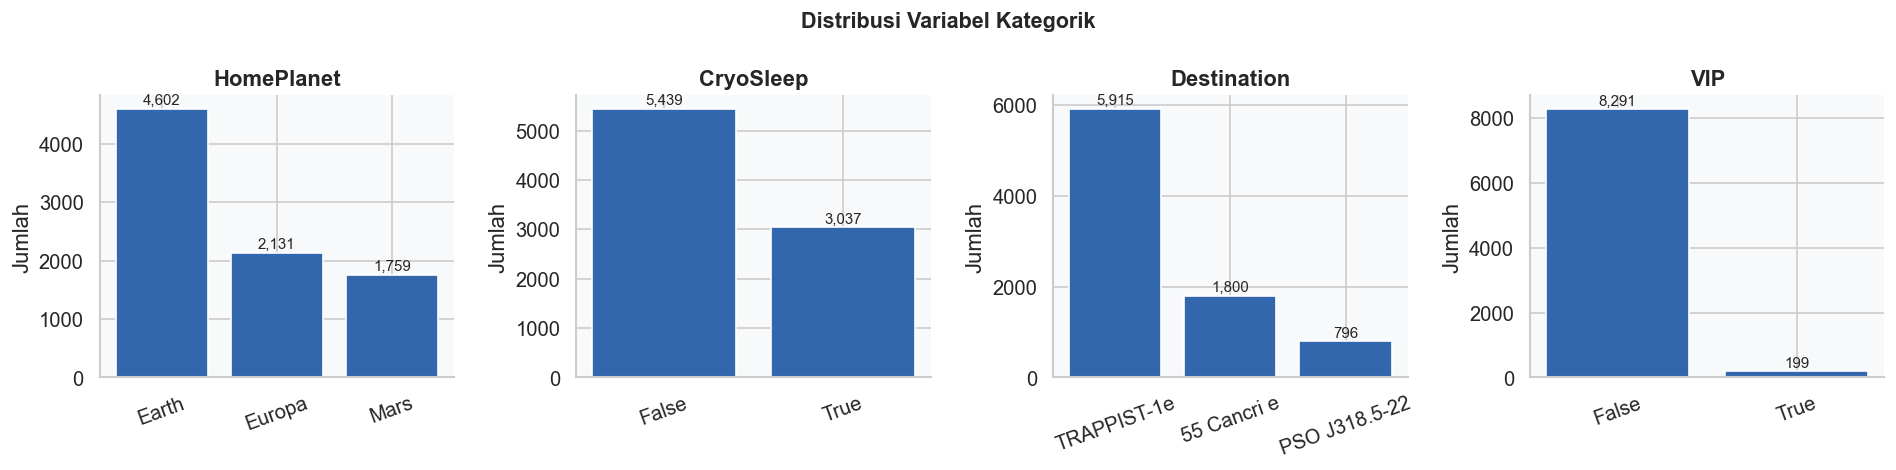

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    vc = train[col].value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values, color='#3266ad', edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribusi Variabel Kategorik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dist_kategorik.png', bbox_inches='tight')
plt.show()

## 7. Analisis Target (Transported)

Distribusi Target:
             Count  Pct (%)
Transported                
True          4378    50.36
False         4315    49.64


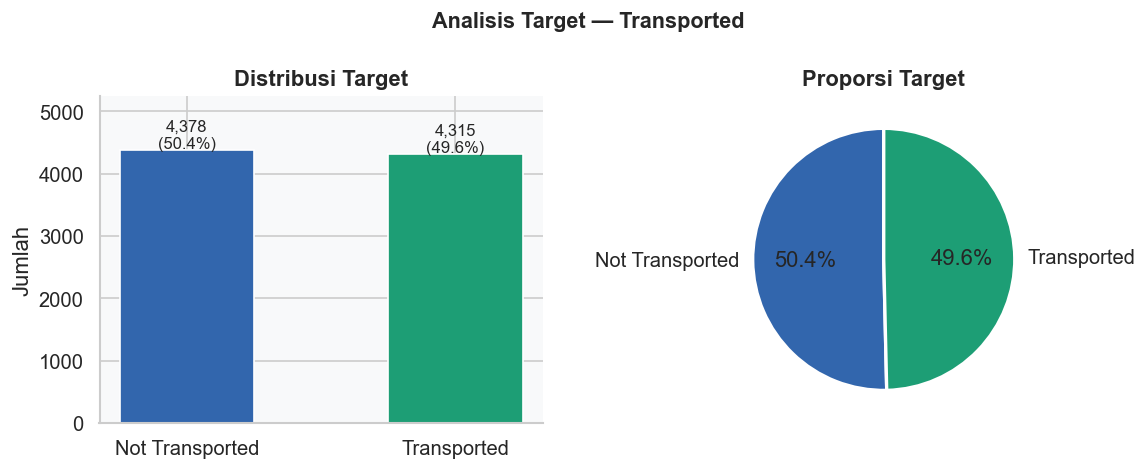

In [11]:
target_counts = train['Transported'].value_counts()
target_pct    = train['Transported'].value_counts(normalize=True) * 100

print('Distribusi Target:')
print(pd.DataFrame({'Count': target_counts, 'Pct (%)': target_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
ax = axes[0]
bars = ax.bar(['Not Transported', 'Transported'], target_counts.values, color=PALETTE, edgecolor='white', width=0.5)
for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(train)*100:.1f}%)', ha='center', fontsize=10)
ax.set_title('Distribusi Target', fontweight='bold')
ax.set_ylabel('Jumlah')
ax.set_ylim(0, max(target_counts.values) * 1.2)

# Pie chart
ax = axes[1]
ax.pie(target_counts.values, labels=['Not Transported', 'Transported'],
       colors=PALETTE, autopct='%1.1f%%', startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Proporsi Target', fontweight='bold')

plt.suptitle('Analisis Target — Transported', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('target_dist.png', bbox_inches='tight')
plt.show()

## 8. Analisis Fitur vs Target

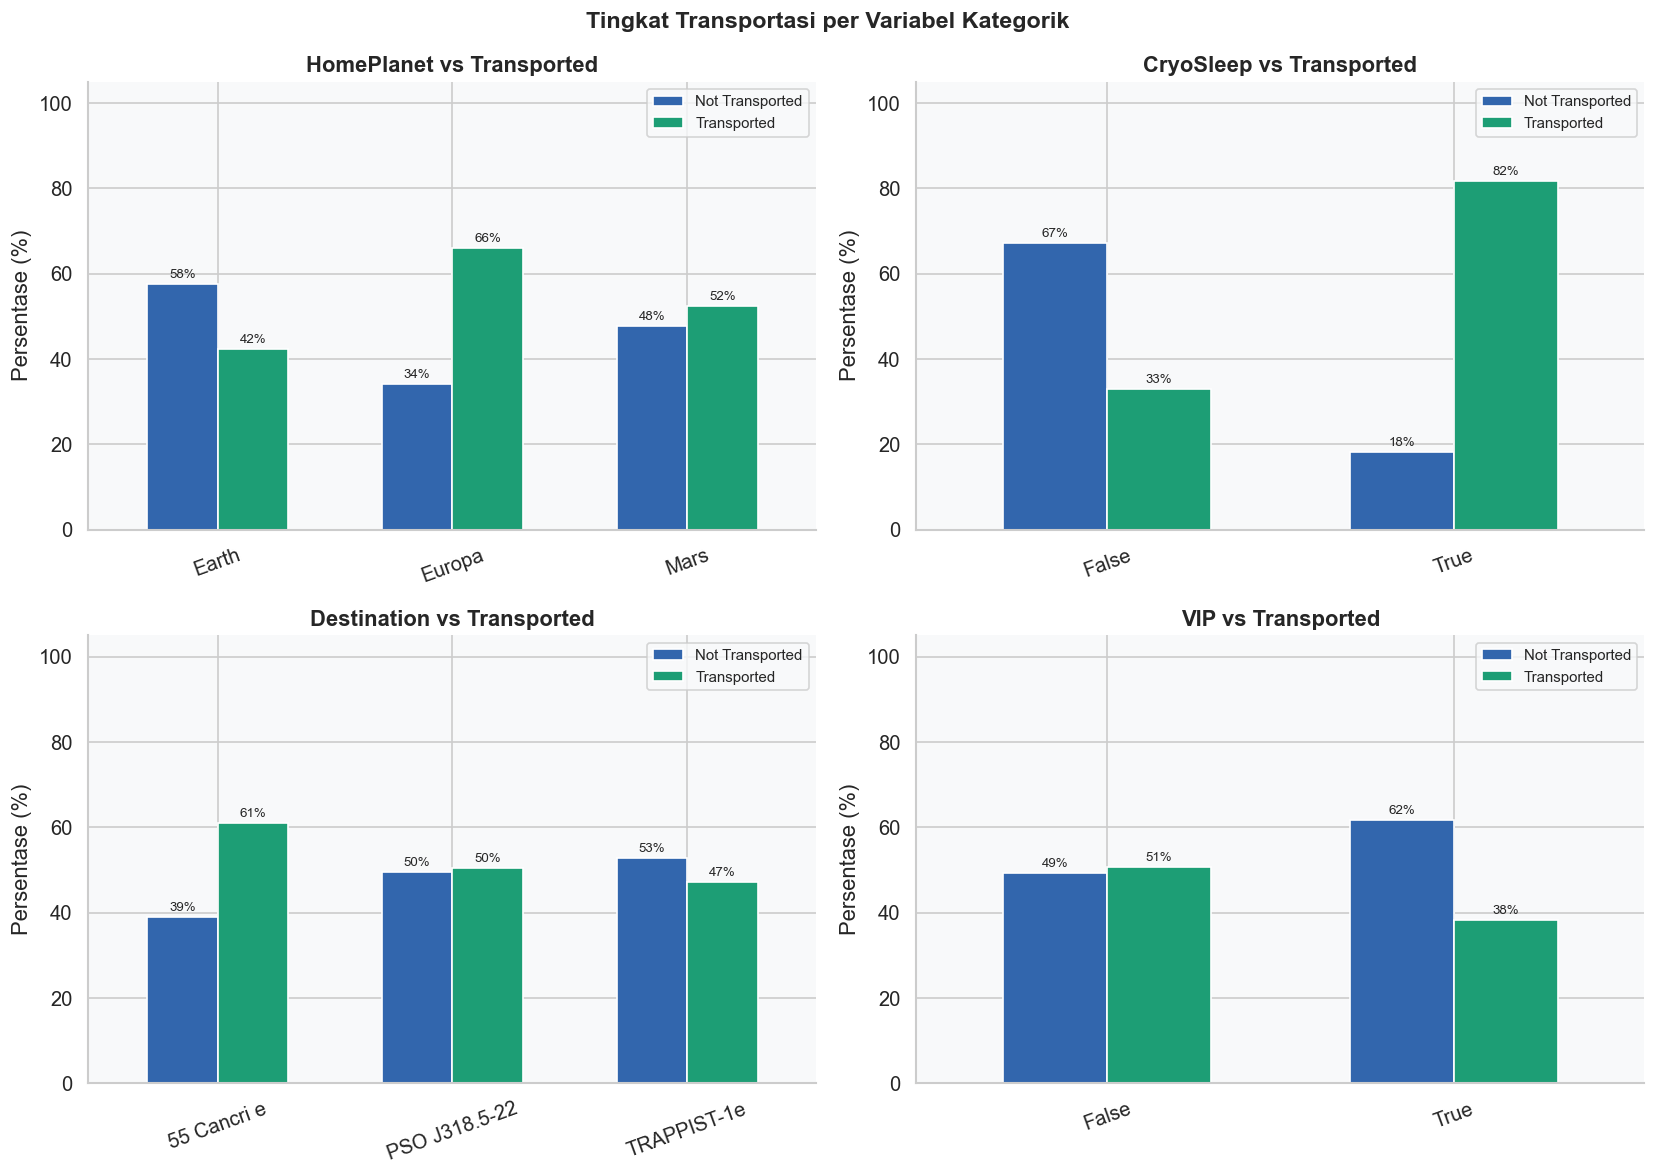

In [12]:
# ── 8.1 Variabel kategorik vs target ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    ct = train.groupby(col)['Transported'].value_counts(normalize=True).unstack() * 100
    ct.rename(columns={False: 'Not Transported', True: 'Transported'}, inplace=True)
    ct[['Not Transported', 'Transported']].plot(
        kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.6
    )
    ax.set_title(f'{col} vs Transported', fontweight='bold')
    ax.set_ylabel('Persentase (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 105)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', fontsize=8, padding=2)

plt.suptitle('Tingkat Transportasi per Variabel Kategorik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cat_vs_target.png', bbox_inches='tight')
plt.show()

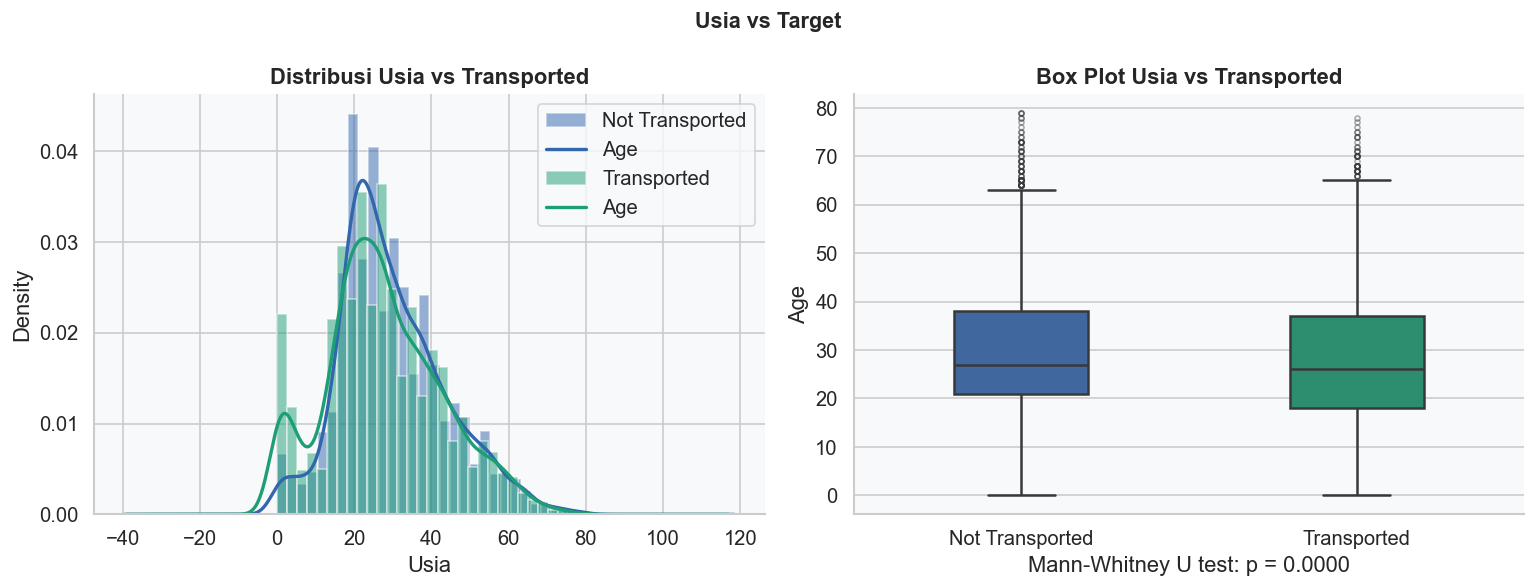

In [13]:
# ── 8.2 Usia vs target ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# KDE plot
ax = axes[0]
for transported, color, label in [(False, C_FALSE, 'Not Transported'), (True, C_TRUE, 'Transported')]:
    data = train[train['Transported'] == transported]['Age'].dropna()
    ax.hist(data, bins=30, alpha=0.5, color=color, label=label, density=True, edgecolor='white')
    data.plot.kde(ax=ax, color=color, linewidth=2)
ax.set_title('Distribusi Usia vs Transported', fontweight='bold')
ax.set_xlabel('Usia')
ax.set_ylabel('Density')
ax.legend()

# Box plot
ax = axes[1]
sns.boxplot(data=train, x='Transported', y='Age', palette=PALETTE, ax=ax,
            width=0.4, linewidth=1.5, flierprops={'marker':'o','markersize':3,'alpha':0.4})
ax.set_title('Box Plot Usia vs Transported', fontweight='bold')
ax.set_xticklabels(['Not Transported', 'Transported'])

# Mann-Whitney U test
grp_f = train[train['Transported'] == False]['Age'].dropna()
grp_t = train[train['Transported'] == True]['Age'].dropna()
stat, p = stats.mannwhitneyu(grp_f, grp_t)
ax.set_xlabel(f'Mann-Whitney U test: p = {p:.4f}')

plt.suptitle('Usia vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('age_vs_target.png', bbox_inches='tight')
plt.show()

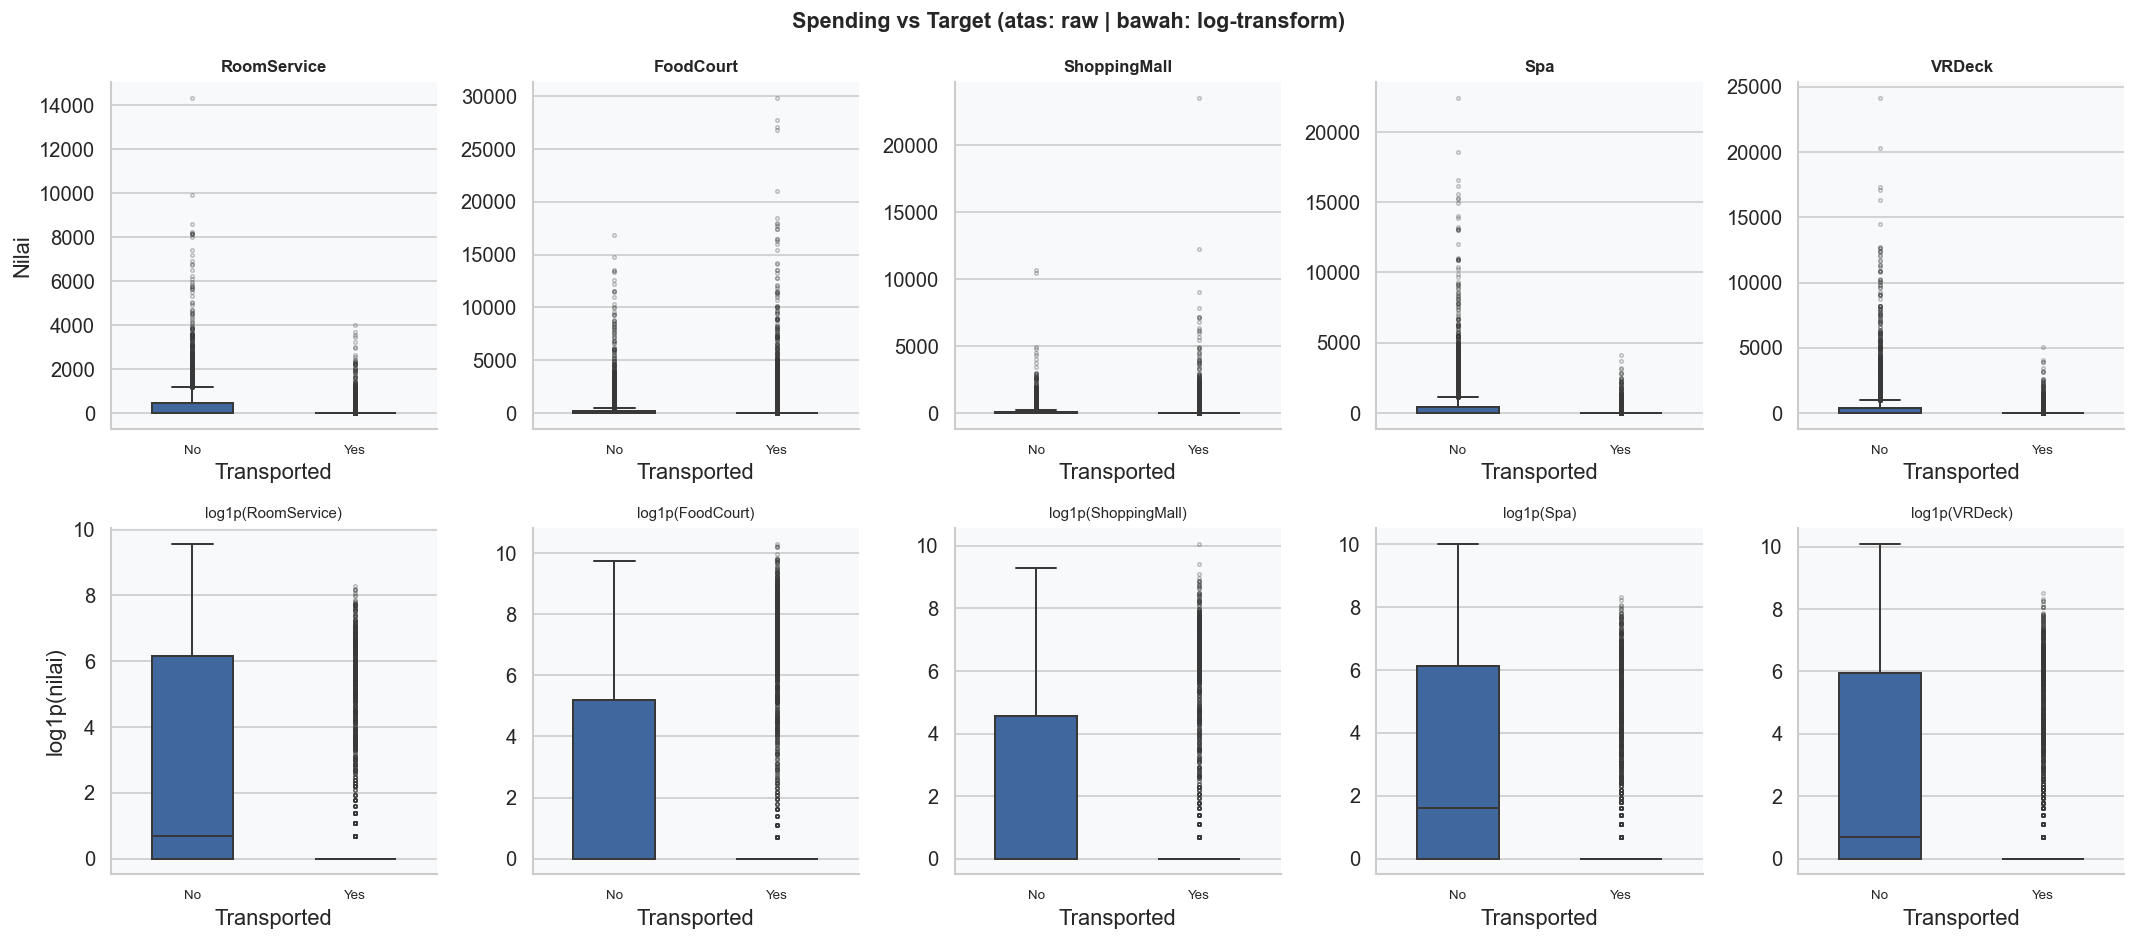

In [14]:
# ── 8.3 Spending vs target ───────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(SPEND_COLS):
    # Raw
    ax = axes[0, i]
    sns.boxplot(data=train, x='Transported', y=col, palette=PALETTE, ax=ax,
                width=0.5, linewidth=1.2, flierprops={'marker':'o','markersize':2,'alpha':0.3})
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xticklabels(['No', 'Yes'], fontsize=8)
    ax.set_xlabel('Transported')
    ax.set_ylabel('Nilai' if i == 0 else '')

    # Log-transform
    ax2 = axes[1, i]
    tmp = train.copy()
    tmp[col] = np.log1p(tmp[col])
    sns.boxplot(data=tmp, x='Transported', y=col, palette=PALETTE, ax=ax2,
                width=0.5, linewidth=1.2, flierprops={'marker':'o','markersize':2,'alpha':0.3})
    ax2.set_title(f'log1p({col})', fontsize=9)
    ax2.set_xticklabels(['No', 'Yes'], fontsize=8)
    ax2.set_xlabel('Transported')
    ax2.set_ylabel('log1p(nilai)' if i == 0 else '')

plt.suptitle('Spending vs Target (atas: raw | bawah: log-transform)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('spend_vs_target.png', bbox_inches='tight')
plt.show()

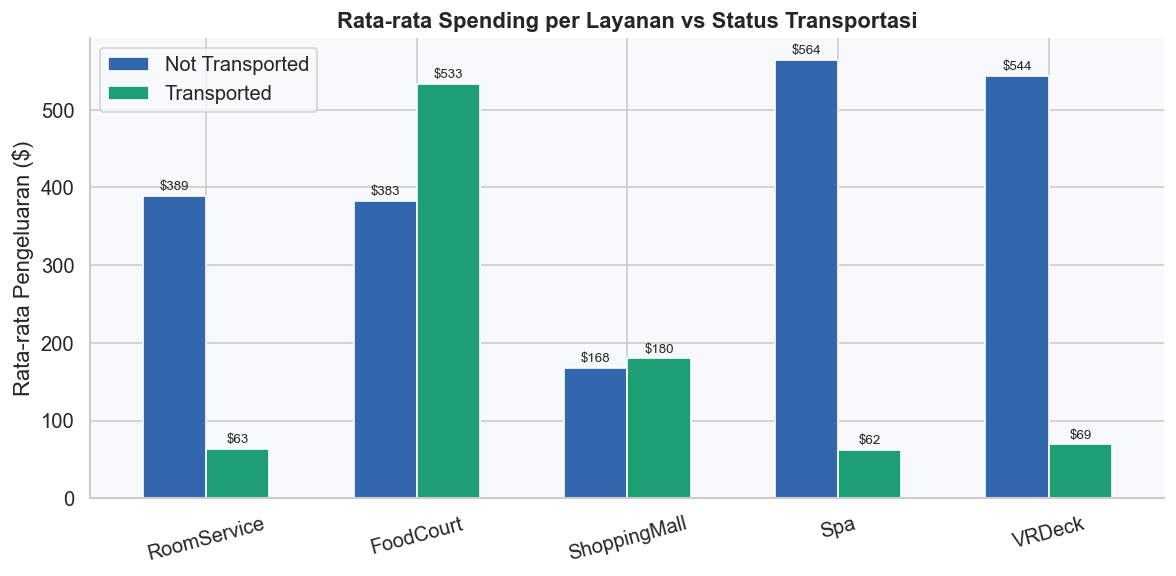

In [15]:
# ── 8.4 Rata-rata spending per grup ──────────────────────────
spend_mean = train.groupby('Transported')[SPEND_COLS].mean().T
spend_mean.columns = ['Not Transported', 'Transported']

ax = spend_mean.plot(kind='bar', figsize=(10, 5), color=PALETTE, edgecolor='white', width=0.6)
ax.set_title('Rata-rata Spending per Layanan vs Status Transportasi', fontweight='bold')
ax.set_ylabel('Rata-rata Pengeluaran ($)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', fontsize=8, padding=2)
plt.tight_layout()
plt.savefig('spend_mean_vs_target.png', bbox_inches='tight')
plt.show()

## 9. Feature Engineering Awal

In [16]:
df = train.copy()

# ── Ekstrak fitur dari PassengerId ───────────────────────────
# Format: XXXX_YY  (grup_nomor)
df['Group']        = df['PassengerId'].str.split('_').str[0].astype(int)
df['GroupMember']  = df['PassengerId'].str.split('_').str[1].astype(int)
df['GroupSize']    = df.groupby('Group')['Group'].transform('count')
df['IsSolo']       = (df['GroupSize'] == 1).astype(int)

# ── Ekstrak fitur dari Cabin ──────────────────────────────────
# Format: Deck/Num/Side
cabin_split      = df['Cabin'].str.split('/', expand=True)
df['CabinDeck']  = cabin_split[0]
df['CabinNum']   = pd.to_numeric(cabin_split[1], errors='coerce')
df['CabinSide']  = cabin_split[2]

# ── Total spending ────────────────────────────────────────────
df['TotalSpend']   = df[SPEND_COLS].sum(axis=1)
df['HasSpending']  = (df['TotalSpend'] > 0).astype(int)

# ── Ekstrak firstname dari Name ───────────────────────────────
df['FirstName'] = df['Name'].str.split().str[0]
df['LastName']  = df['Name'].str.split().str[-1]

print('Fitur baru berhasil dibuat:')
new_cols = ['Group','GroupMember','GroupSize','IsSolo','CabinDeck','CabinNum','CabinSide','TotalSpend','HasSpending']
print(df[new_cols].head(10).to_string())

Fitur baru berhasil dibuat:
   Group  GroupMember  GroupSize  IsSolo CabinDeck  CabinNum CabinSide  TotalSpend  HasSpending
0      1            1          1       1         B       0.0         P         0.0            0
1      2            1          1       1         F       0.0         S       736.0            1
2      3            1          2       0         A       0.0         S     10383.0            1
3      3            2          2       0         A       0.0         S      5176.0            1
4      4            1          1       1         F       1.0         S      1091.0            1
5      5            1          1       1         F       0.0         P       774.0            1
6      6            1          2       0         F       2.0         S      1584.0            1
7      6            2          2       0         G       0.0         S         0.0            0
8      7            1          1       1         F       3.0         S      1018.0            1
9      8    

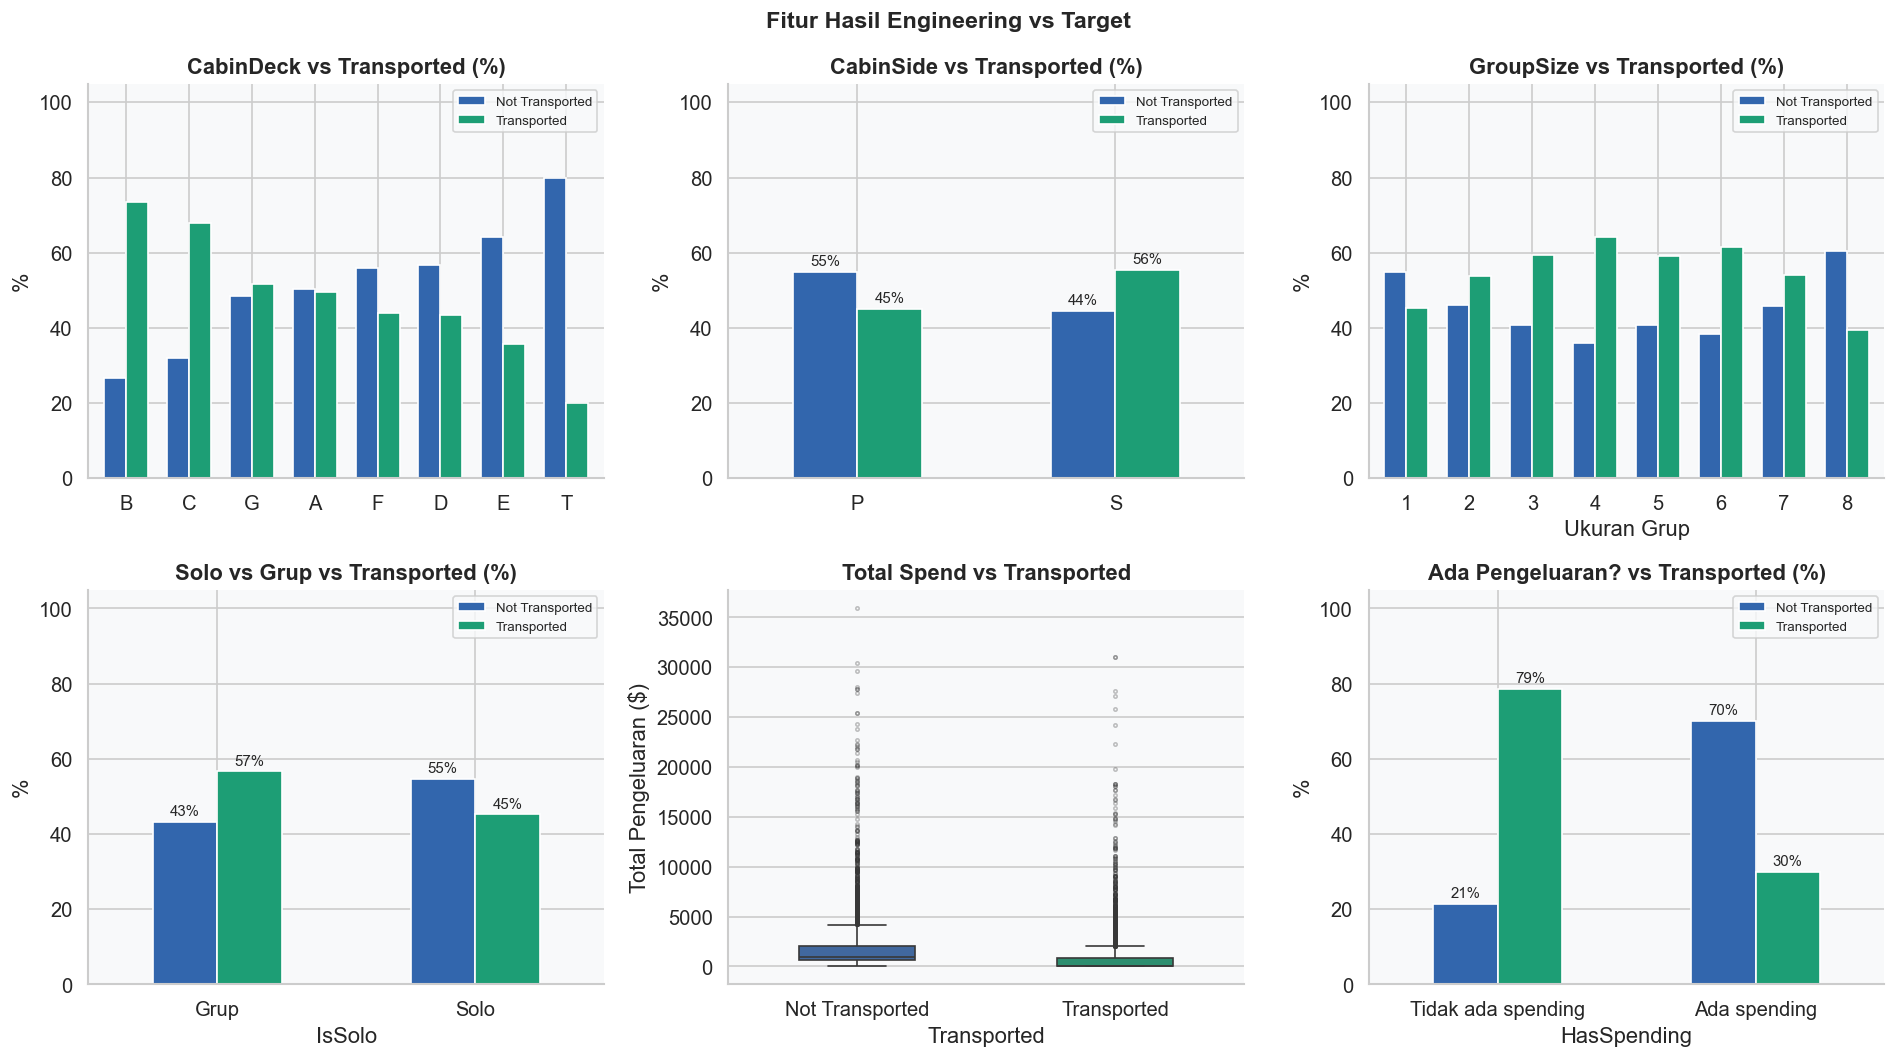

In [17]:
# ── Visualisasi fitur engineering ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# CabinDeck vs Transported
ax = axes[0]
ct = df.groupby('CabinDeck')['Transported'].value_counts(normalize=True).unstack() * 100
ct.rename(columns={False: 'Not Transported', True: 'Transported'}, inplace=True)
ct.sort_values('Transported', ascending=False)[['Not Transported', 'Transported']].plot(
    kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.7)
ax.set_title('CabinDeck vs Transported (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8); ax.set_ylim(0, 105)

# CabinSide vs Transported
ax = axes[1]
ct2 = df.groupby('CabinSide')['Transported'].value_counts(normalize=True).unstack() * 100
ct2.rename(columns={False: 'Not Transported', True: 'Transported'}, inplace=True)
ct2[['Not Transported', 'Transported']].plot(
    kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.5)
ax.set_title('CabinSide vs Transported (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel(''); ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8); ax.set_ylim(0, 105)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=9, padding=2)

# GroupSize vs Transported
ax = axes[2]
ct3 = df.groupby('GroupSize')['Transported'].value_counts(normalize=True).unstack() * 100
ct3.rename(columns={False: 'Not Transported', True: 'Transported'}, inplace=True)
ct3[['Not Transported', 'Transported']].plot(
    kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.7)
ax.set_title('GroupSize vs Transported (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel('Ukuran Grup'); ax.tick_params(axis='x', rotation=0)
ax.legend(fontsize=8); ax.set_ylim(0, 105)

# IsSolo vs Transported
ax = axes[3]
ct4 = df.groupby('IsSolo')['Transported'].value_counts(normalize=True).unstack() * 100
ct4.rename(columns={False: 'Not Transported', True: 'Transported'}, inplace=True)
ct4[['Not Transported', 'Transported']].plot(
    kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.5)
ax.set_title('Solo vs Grup vs Transported (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xticklabels(['Grup', 'Solo'], rotation=0)
ax.legend(fontsize=8); ax.set_ylim(0, 105)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=9, padding=2)

# TotalSpend vs Transported
ax = axes[4]
sns.boxplot(data=df, x='Transported', y='TotalSpend', palette=PALETTE, ax=ax,
            width=0.45, flierprops={'marker':'o','markersize':2,'alpha':0.3})
ax.set_title('Total Spend vs Transported', fontweight='bold')
ax.set_xticklabels(['Not Transported', 'Transported'])
ax.set_ylabel('Total Pengeluaran ($)')

# HasSpending vs Transported
ax = axes[5]
ct5 = df.groupby('HasSpending')['Transported'].value_counts(normalize=True).unstack() * 100
ct5.rename(columns={False: 'Not Transported', True: 'Transported'}, inplace=True)
ct5[['Not Transported', 'Transported']].plot(
    kind='bar', ax=ax, color=PALETTE, edgecolor='white', width=0.5)
ax.set_title('Ada Pengeluaran? vs Transported (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xticklabels(['Tidak ada spending', 'Ada spending'], rotation=0)
ax.legend(fontsize=8); ax.set_ylim(0, 105)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', fontsize=9, padding=2)

plt.suptitle('Fitur Hasil Engineering vs Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_engineering.png', bbox_inches='tight')
plt.show()

## 10. Korelasi & Heatmap

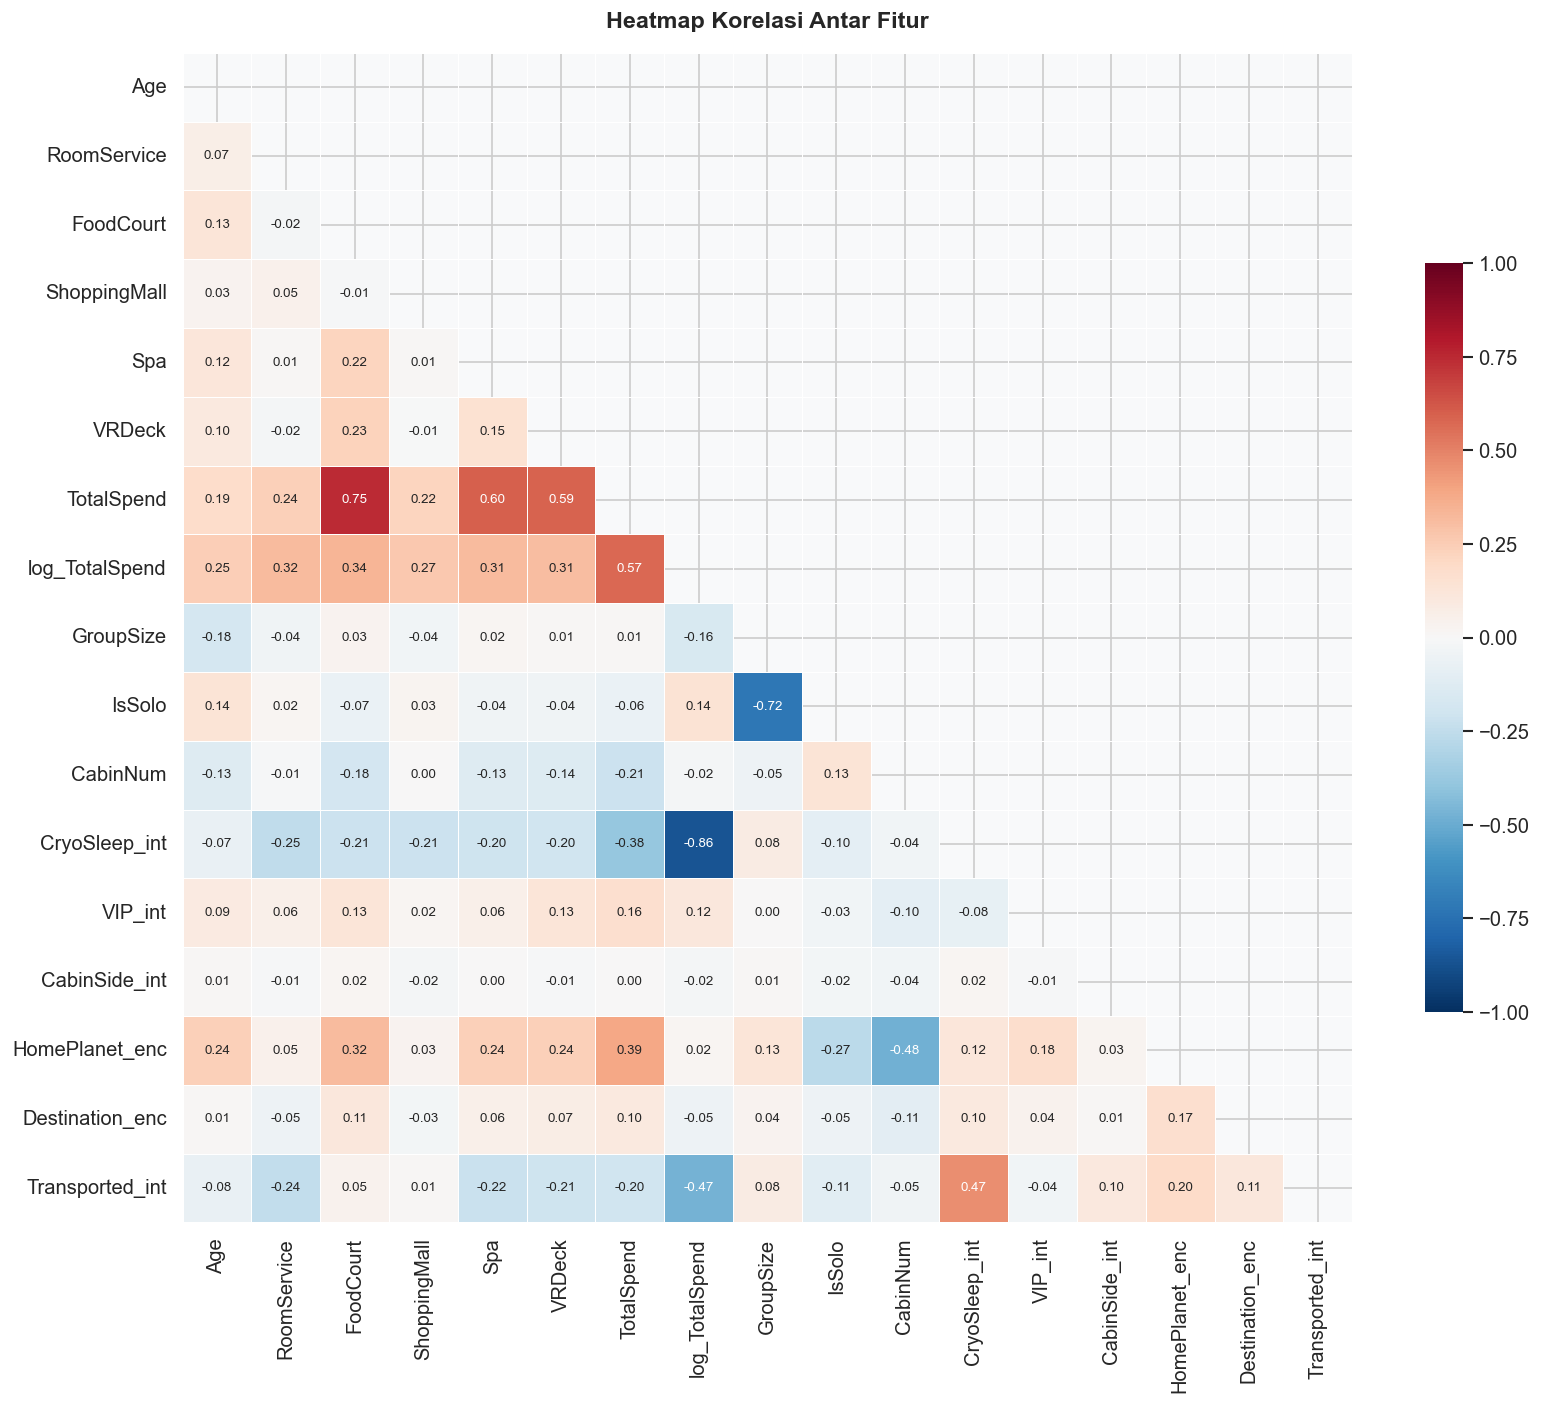

In [18]:
# Encode variabel untuk korelasi
df_corr = df.copy()
df_corr['Transported_int']  = df_corr['Transported'].astype(int)
df_corr['CryoSleep_int']    = df_corr['CryoSleep'].map({'True': 1, 'False': 0, True: 1, False: 0})
df_corr['VIP_int']          = df_corr['VIP'].map({'True': 1, 'False': 0, True: 1, False: 0})
df_corr['CabinSide_int']    = df_corr['CabinSide'].map({'P': 0, 'S': 1})
df_corr['HomePlanet_enc']   = df_corr['HomePlanet'].map({'Earth': 0, 'Mars': 1, 'Europa': 2})
df_corr['Destination_enc']  = df_corr['Destination'].map({'TRAPPIST-1e': 0, 'PSO J318.5-22': 1, '55 Cancri e': 2})
df_corr['log_TotalSpend']   = np.log1p(df_corr['TotalSpend'])

CORR_COLS = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
             'TotalSpend', 'log_TotalSpend', 'GroupSize', 'IsSolo', 'CabinNum',
             'CryoSleep_int', 'VIP_int', 'CabinSide_int', 'HomePlanet_enc',
             'Destination_enc', 'Transported_int']

corr_matrix = df_corr[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            annot_kws={'size': 8}, square=True,
            cbar_kws={'shrink': 0.6})
ax.set_title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', bbox_inches='tight')
plt.show()

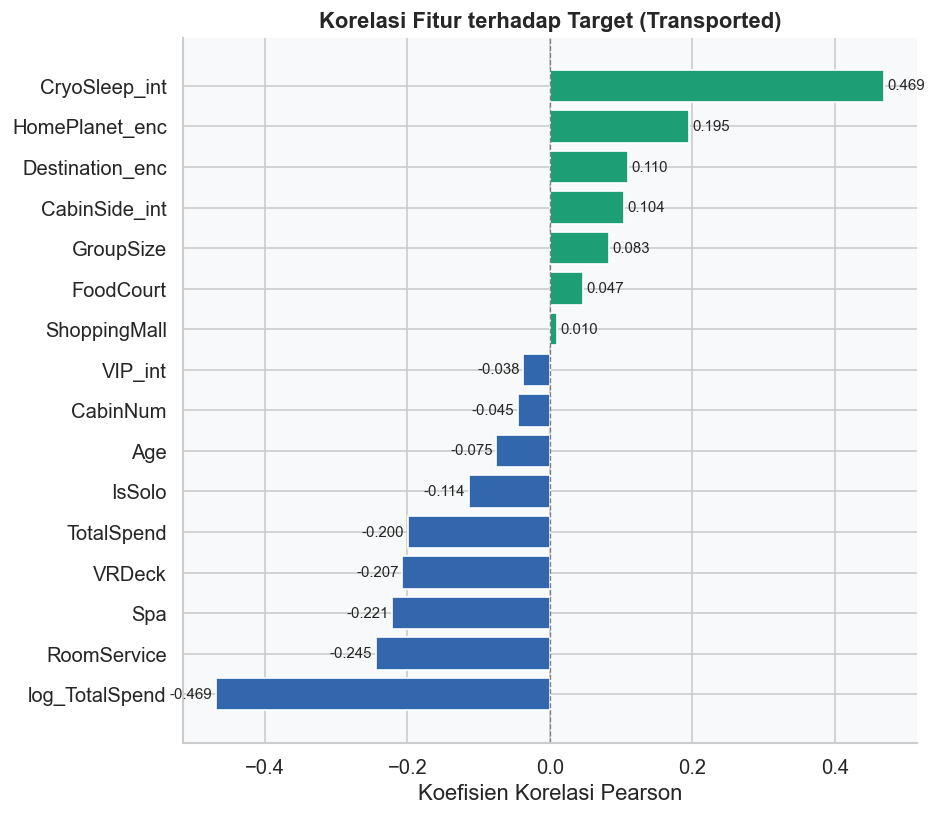

In [19]:
# Korelasi fitur terhadap target — diurutkan
target_corr = corr_matrix['Transported_int'].drop('Transported_int').sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = [C_FALSE if v < 0 else C_TRUE for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Korelasi Fitur terhadap Target (Transported)', fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson')
for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('korelasi_target.png', bbox_inches='tight')
plt.show()

## 11. Outlier Detection

In [20]:
def detect_outliers_iqr(series):
    """Deteksi outlier dengan metode IQR."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

print(f'{"Kolom":<15} {"Outlier":<10} {"Pct (%)":<10} {"Lower":<12} {"Upper"}')
print('-' * 60)
for col in NUM_COLS:
    data = train[col].dropna()
    n_out, lo, hi = detect_outliers_iqr(data)
    print(f'{col:<15} {n_out:<10} {n_out/len(data)*100:<10.2f} {lo:<12.1f} {hi:.1f}')

Kolom           Outlier    Pct (%)    Lower        Upper
------------------------------------------------------------
Age             77         0.90       -9.5         66.5
RoomService     1861       21.86      -70.5        117.5
FoodCourt       1823       21.42      -114.0       190.0
ShoppingMall    1829       21.56      -40.5        67.5
Spa             1788       21.01      -88.5        147.5
VRDeck          1809       21.27      -69.0        115.0


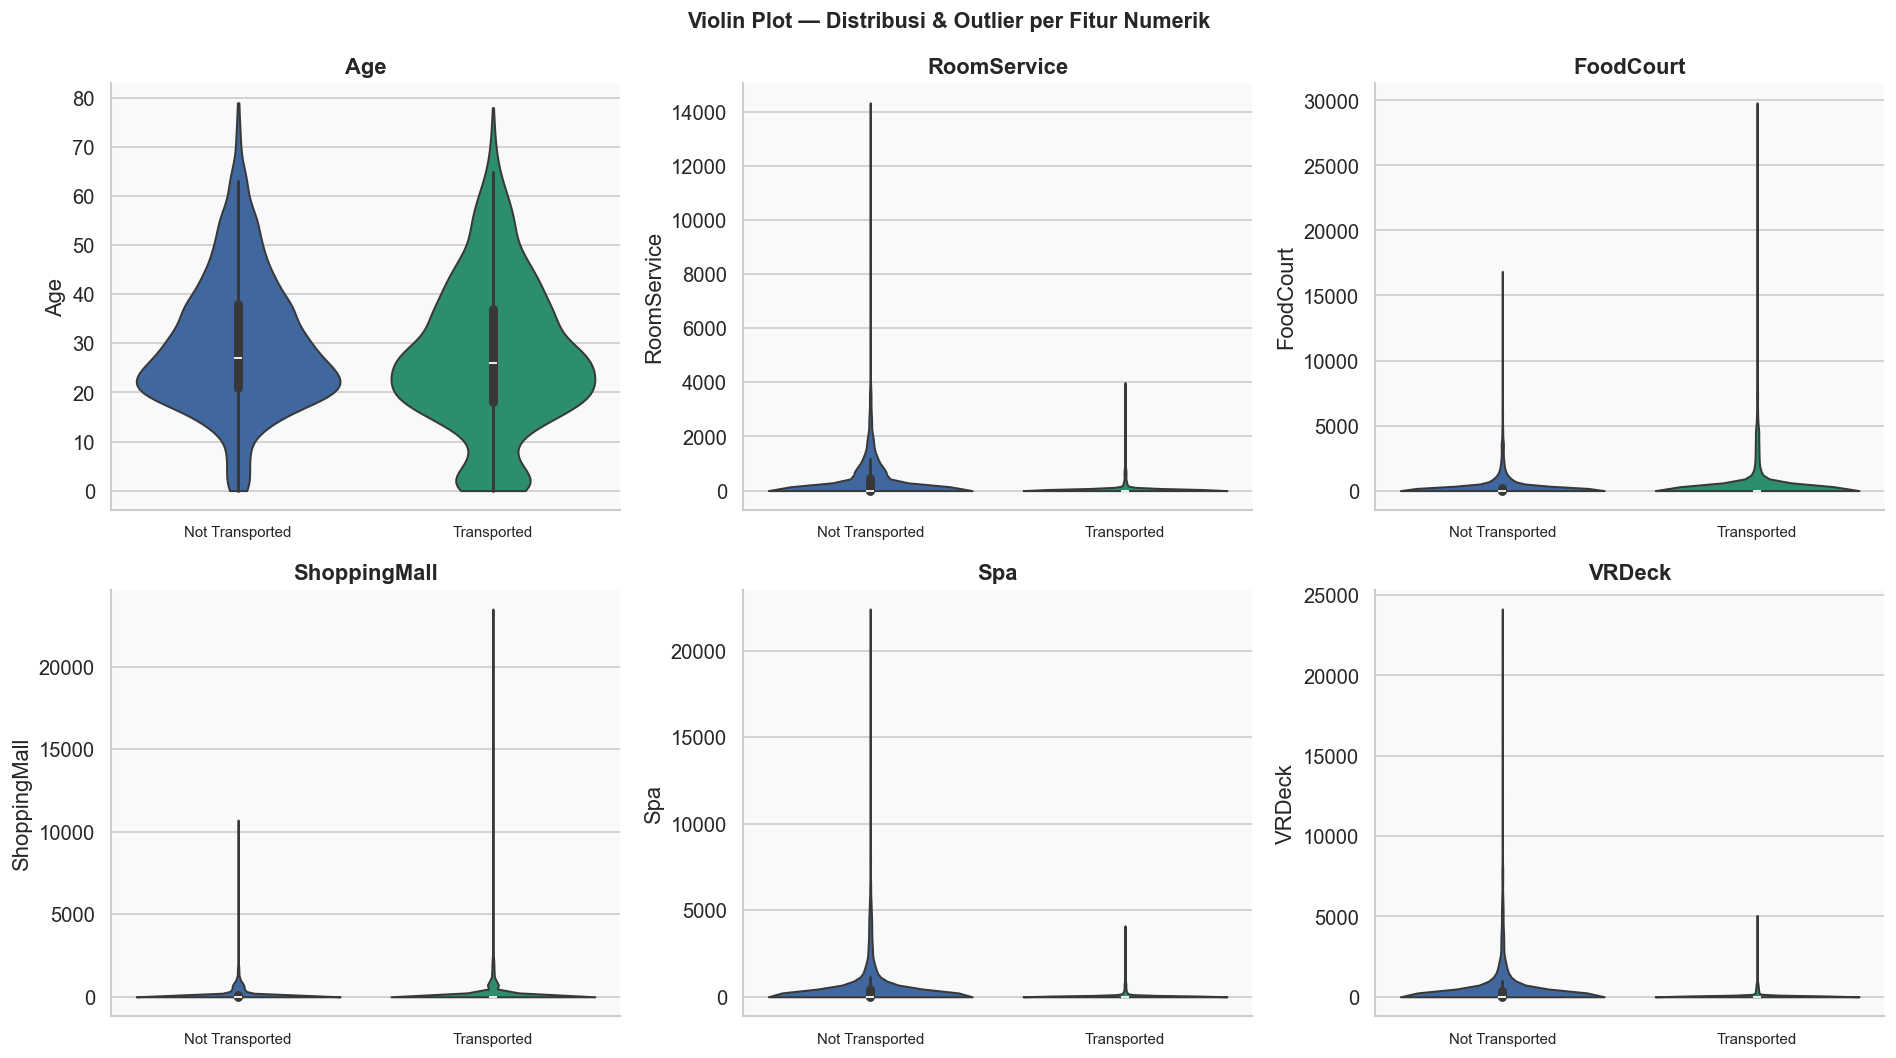

In [21]:
# Visualisasi outlier dengan violin + box plot
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    tmp = train[[col, 'Transported']].dropna()
    sns.violinplot(data=tmp, x='Transported', y=col, palette=PALETTE, ax=ax,
                   inner='box', linewidth=1.2, cut=0)
    ax.set_title(col, fontweight='bold')
    ax.set_xticklabels(['Not Transported', 'Transported'], fontsize=9)
    ax.set_xlabel('')

plt.suptitle('Violin Plot — Distribusi & Outlier per Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('violin_outlier.png', bbox_inches='tight')
plt.show()

## 12. Ringkasan Temuan EDA

In [22]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          RINGKASAN TEMUAN EDA — SPACESHIP TITANIC               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET                                                         ║
║  • 8,693 baris train | 4,277 baris test | 13 fitur + 1 target   ║
║  • Target sangat seimbang: 50.4% vs 49.6% → tidak perlu        ║
║    oversampling/undersampling                                     ║
║                                                                  ║
║  MISSING VALUES                                                  ║
║  • Semua kolom memiliki ~2% missing → imputasi diperlukan        ║
║  • Kolom kategori: imputasi modus                                ║
║  • Kolom numerik: imputasi median (skewed distribution)          ║
║                                                                  ║
║  PREDIKTOR TERKUAT                                               ║
║  1. CryoSleep: penumpang cryo → 81.8% ditransportasi            ║
║  2. HasSpending: tanpa spending → lebih banyak ditransportasi   ║
║  3. HomePlanet: Europa (65.9%) > Mars (52.3%) > Earth (42.4%)  ║
║  4. CabinDeck: deck B & G paling banyak ditransportasi          ║
║  5. RoomService & Spa: korelasi negatif dengan transported       ║
║                                                                  ║
║  DISTRIBUSI NUMERIK                                              ║
║  • Kolom spending sangat right-skewed → gunakan log-transform   ║
║  • Usia terdistribusi normal, rata-rata ~29 tahun               ║
║  • Anak-anak (usia < 18) lebih banyak ditransportasi            ║
║                                                                  ║
║  FITUR ENGINEERING REKOMENDASI                                   ║
║  • TotalSpend = sum semua spending                               ║
║  • HasSpending = bool apakah ada pengeluaran                     ║
║  • GroupSize dari PassengerId                                    ║
║  • IsSolo (perjalanan sendiri vs grup)                           ║
║  • CabinDeck, CabinNum, CabinSide dari Cabin                    ║
║  • Log-transform kolom spending untuk modeling                   ║
║                                                                  ║
║  LANGKAH SELANJUTNYA                                             ║
║  → Imputasi missing values                                       ║
║  → Encoding variabel kategorik (OHE / Label Encoding)           ║
║  → Feature selection / importance analysis                       ║
║  → Modeling (XGBoost, LightGBM, RandomForest)                   ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          RINGKASAN TEMUAN EDA — SPACESHIP TITANIC               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  DATASET                                                         ║
║  • 8,693 baris train | 4,277 baris test | 13 fitur + 1 target   ║
║  • Target sangat seimbang: 50.4% vs 49.6% → tidak perlu        ║
║    oversampling/undersampling                                     ║
║                                                                  ║
║  MISSING VALUES                                                  ║
║  • Semua kolom memiliki ~2% missing → imputasi diperlukan        ║
║  • Kolom kategori: imputasi modus                                ║
║  • Kolom numerik: imputasi median (skewed distribution)          ║
║                                                                  ║
║  PREDIKTOR TERKUAT                